In [1]:
import os
from dotenv import load_dotenv, find_dotenv #to load in api key

import truststore
truststore.inject_into_ssl() #For later when we have to load data from Madrid's census population

load_dotenv(find_dotenv("apikey.env", usecwd=True))
KEY = os.environ["OCM_API_KEY"]

In [2]:
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import pandas as pd #for EDA
import ocm_extract as ocm #API that allows us to access the chargers in the first place
print("Working in:", os.getcwd())

Working in: e:\CodingProjects\ChargingStation


In [3]:
#pulling information from Open Charger Map
ref = ocm.get("referencedata")
usage = {u["ID"]: u for u in ref["UsageTypes"]}
status = {s["ID"]: s for s in ref["StatusTypes"]}
operators = {o["ID"]: o["Title"] for o in ref["Operators"]}

pois = []
for tile in ocm.grid(ocm.BBOX_CITY):
    pois += ocm.fetch_recursive(tile)
deduped = {p["ID"]: p for p in pois}
print(len(deduped), "unique chargers")

df = pd.DataFrame(ocm.flatten(p, usage, status) for p in deduped.values())
df["access_class"] = df.apply(ocm.access_class, axis=1)
df["operator"] = df["operator_id"].map(operators)
df.to_csv("data/raw/ocm/ocm_chargers_city_test.csv", index=False)

(40.31, -3.89, 40.41, -3.79) -> 124
(40.31, -3.79, 40.41, -3.69) -> 206
(40.31, -3.69, 40.41, -3.59) -> 135
(40.31, -3.59, 40.41, -3.52) -> 55
(40.41, -3.89, 40.51, -3.79) -> 100
(40.41, -3.79, 40.51, -3.69) -> 232
(40.41, -3.69, 40.51, -3.59) -> 326
(40.41, -3.59, 40.51, -3.52) -> 92
(40.51, -3.89, 40.61, -3.79) -> 8
(40.51, -3.79, 40.61, -3.69) -> 27
(40.51, -3.69, 40.61, -3.59) -> 142
(40.51, -3.59, 40.61, -3.52) -> 7
(40.61, -3.89, 40.64, -3.79) -> 0
(40.61, -3.79, 40.64, -3.69) -> 14
(40.61, -3.69, 40.64, -3.59) -> 1
(40.61, -3.59, 40.64, -3.52) -> 1
1470 unique chargers


## Exploring Charging sites

In [4]:
pd.crosstab(df["usage_type"].fillna("(missing)"), df["access_class"])

access_class,public,public_membership,restricted
usage_type,,,
"Private - For Staff, Visitors or Customers",0,0,304
Private - Restricted Access,0,0,111
Privately Owned - Notice Required,0,0,3
Public,88,0,0
Public - Membership Required,0,887,0
Public - Pay At Location,77,0,0


In [5]:
#That is a lot of public membership locations? Let's take a look at the data itself

df[df["access_class"] == "public_membership"]["operator"].value_counts().head(10)

operator
Iberdrola | BP Pulse (ES)       171
Endesa                           93
Mercadona                        86
Repsol - Ibil (ES)               85
EDP                              81
Wenea                            37
TotalEnergies (ES)               31
(Business Owner at Location)     24
Electromaps                      22
Eranovum (ES)                    19
Name: count, dtype: int64

In [6]:
df.loc[df["access_class"] == "public_membership", "operator"].value_counts(dropna=False).tail(15)


operator
GIC                            5
Carrefour (ES)                 3
Naturgy (ES)                   3
Ballenoil (ES)                 3
Place To Plug                  3
Ionity                         3
Telpark (ES)                   3
eTecnic                        3
PowerGo                        2
Fenie Energía (Spain)          2
Interparking (ES)              2
Porsche Smart Mobility GmbH    1
Plenitude On The Road (EU)     1
Electrico.es                   1
Lidl                           1
Name: count, dtype: int64

In [7]:
df["is_public"] = df["access_class"].isin(["public", "public_membership"])
pub = df[df["is_public"]]
print(len(pub), "public sites,", pub["n_points"].sum(), "charging points")
print("missing n_points:", pub["n_points"].isna().mean().round(2))
print(pub["max_power_kw"].describe())

1052 public sites, 5817.0 charging points
missing n_points: 0.0
count    1052.000000
mean       60.861036
std        72.618477
min         1.000000
25%        22.000000
50%        30.000000
75%        80.000000
max       600.000000
Name: max_power_kw, dtype: float64


## Exploring BBOX_city

In [8]:
import json

ref = ocm.get("referencedata")
usage = {u["ID"]: u for u in ref["UsageTypes"]}
status = {s["ID"]: s for s in ref["StatusTypes"]}
operators = {o["ID"]: o["Title"] for o in ref["Operators"]}

pois = []
for tile in ocm.grid(ocm.BBOX_COMUNIDAD):
    pois += ocm.fetch_recursive(tile)
deduped = {p["ID"]: p for p in pois}
print(len(deduped), "unique sites")

with open("data/raw/ocm/ocm_raw.json", "w", encoding="utf-8") as f:
    json.dump(list(deduped.values()), f, ensure_ascii=False)

df = pd.DataFrame(ocm.flatten(p, usage, status) for p in deduped.values())
df["access_class"] = df.apply(ocm.access_class, axis=1)
df["operator"] = df["operator_id"].map(operators)
df["is_public"] = df["access_class"].isin(["public", "public_membership"])
df.to_csv("data/raw/ocm/ocm_chargers.csv", index=False)
df["access_class"].value_counts()

(39.88, -4.58, 39.98, -4.48) -> 0
(39.88, -4.48, 39.98, -4.38) -> 0
(39.88, -4.38, 39.98, -4.28) -> 1
(39.88, -4.28, 39.98, -4.18) -> 1
(39.88, -4.18, 39.98, -4.08) -> 0
(39.88, -4.08, 39.98, -3.98) -> 22
(39.88, -3.98, 39.98, -3.88) -> 1
(39.88, -3.88, 39.98, -3.78) -> 1
(39.88, -3.78, 39.98, -3.68) -> 0
(39.88, -3.68, 39.98, -3.58) -> 0
(39.88, -3.58, 39.98, -3.48) -> 5
(39.88, -3.48, 39.98, -3.38) -> 2
(39.88, -3.38, 39.98, -3.28) -> 0
(39.88, -3.28, 39.98, -3.18) -> 0
(39.88, -3.18, 39.98, -3.08) -> 0
(39.88, -3.08, 39.98, -3.05) -> 0
(39.98, -4.58, 40.08, -4.48) -> 1
(39.98, -4.48, 40.08, -4.38) -> 1
(39.98, -4.38, 40.08, -4.28) -> 4
(39.98, -4.28, 40.08, -4.18) -> 2
(39.98, -4.18, 40.08, -4.08) -> 0
(39.98, -4.08, 40.08, -3.98) -> 1
(39.98, -3.98, 40.08, -3.88) -> 2
(39.98, -3.88, 40.08, -3.78) -> 3
(39.98, -3.78, 40.08, -3.68) -> 0
(39.98, -3.68, 40.08, -3.58) -> 20
(39.98, -3.58, 40.08, -3.48) -> 1
(39.98, -3.48, 40.08, -3.38) -> 0
(39.98, -3.38, 40.08, -3.28) -> 0
(39.98, -3.2

access_class
public_membership    1566
restricted            608
public                302
unknown                 1
Name: count, dtype: int64

In [9]:
import os
import osmium, shapely.wkb
import geopandas as gpd
import osmnx as ox
import osm_extract as osm

PBF = "data/raw/osm/madrid-260930.osm.pbf"   # Geofabrik snapshot, OSM data as of 30 Sep 2026

# Create every output folder up front (safe if they already exist)
for d in ["data/raw/osm", "data/raw/boundaries", "data/processed"]:
    os.makedirs(d, exist_ok=True)

if not os.path.exists(PBF):
    raise FileNotFoundError(f"{PBF} not found. Download it from "
                            "https://download.geofabrik.de/europe/spain/madrid-latest.osm.pbf "
                            "and put it in data/raw/osm/")

# Comunidad outline (cached after the first run)
if os.path.exists("data/raw/osm/boundary.gpkg"):
    boundary = gpd.read_file("data/raw/osm/boundary.gpkg")
else:
    boundary = ox.geocode_to_gdf(osm.PLACE)
    boundary.to_file("data/raw/osm/boundary.gpkg")
polygon = boundary.to_crs(4326).geometry.iloc[0]

def matches(tags, rule):
    for k, want in rule.items():
        v = tags.get(k)
        if v is None:
            continue
        if want is True or v == want or (isinstance(want, list) and v in want):
            return True
    return False

keys = sorted({k for rule in osm.LAYERS.values() for k in rule} | {"boundary"})
wkb = osmium.geom.WKBFactory()
rows = {layer: [] for layer in osm.LAYERS}
muni_rows = []

fp = (osmium.FileProcessor(PBF).with_locations()
      .with_areas(osmium.filter.KeyFilter(*keys))
      .with_filter(osmium.filter.KeyFilter(*keys)))

for o in fp:
    if o.is_node():
        kind, make, oid = "node", wkb.create_point, o.id
    elif o.is_area():
        kind = "way" if o.from_way() else "relation"
        make, oid = wkb.create_multipolygon, o.orig_id()
    else:
        continue
    t = dict(o.tags)

    if kind != "node" and t.get("boundary") == "administrative" and t.get("admin_level") == "8":
        try:
            muni_rows.append({"name": t.get("name"), "ine_code": t.get("ine:municipio"),
                              "geometry": shapely.wkb.loads(make(o), hex=True)})
        except Exception:
            pass
        continue

    for layer, rule in osm.LAYERS.items():
        if matches(t, rule):
            try:
                geom = shapely.wkb.loads(make(o), hex=True)
            except Exception:
                continue   # skip broken geometries
            rows[layer].append({"element": kind, "id": oid,
                                **{c: t.get(c) for c in osm.KEEP_COLS}, "geometry": geom})

# Save POI layers (only features inside the Comunidad)
gpkg = "data/raw/osm/osm_pois.gpkg"
for layer, r in rows.items():
    g = gpd.GeoDataFrame(r, crs=4326)
    g = osm.to_points(g)                                   # -> points in EPSG:25830
    g = g[g.to_crs(4326).within(polygon)]
    g = g.dropna(axis=1, how="all")                        # drop tag columns that are all empty
    g.to_file(gpkg, layer=layer)
    print(f"{layer}: {len(g)} saved")

# Save municipalities
munis = gpd.GeoDataFrame(muni_rows, crs=4326)
inside = munis.to_crs(25830).representative_point().to_crs(4326).within(polygon)
munis = munis[inside].to_crs(25830).reset_index(drop=True)
munis.to_file("data/raw/boundaries/municipios.gpkg")
print(len(munis), "municipalities (should be 179),", munis["ine_code"].isna().sum(), "without INE code")

charging: 327 saved
fuel: 864 saved
retail: 4003 saved
office: 3925 saved
food: 11626 saved
transit: 492 saved
parking: 14562 saved
181 municipalities (should be 179), 3 without INE code


In [10]:
pts = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs=4326).to_crs(25830)
pts = gpd.sjoin(pts, munis, how="inner", predicate="within")   # drops points outside the Comunidad

pub = pts[pts["is_public"]]
supply = pd.DataFrame({
    "public_sites":   pub.groupby("ine_code").size(),
    "public_points":  pub.groupby("ine_code")["n_points"].sum(),
    "private_sites":  pts[~pts["is_public"]].groupby("ine_code").size(),
})

fuel = gpd.read_file("data/raw/osm/osm_pois.gpkg", layer="fuel")
fuel = gpd.sjoin(fuel, munis, how="inner", predicate="within")
supply["fuel_stations"] = fuel.groupby("ine_code").size()

munis_supply = munis.merge(supply, left_on="ine_code", right_index=True, how="left")
cols = ["public_sites", "public_points", "private_sites", "fuel_stations"]
munis_supply[cols] = munis_supply[cols].fillna(0).astype(int)
munis_supply["area_km2"] = munis_supply.area / 1e6

munis_supply.drop(columns="geometry").to_csv("data/processed/muni_supply.csv", index=False)
munis_supply.sort_values("public_points", ascending=False).head(15)

,name,ine_code,geometry,public_sites,public_points,private_sites,fuel_stations,area_km2
172,Madrid,28079,"MULTIPOLYGON (((424754.339 4491498.96, 424801....",618,3661,298,248,603.870690
147,Torrejón de Ardoz,28148,"MULTIPOLYGON (((457783.085 4480045.028, 457884...",49,326,7,26,32.622144
141,Alcobendas,28006,"MULTIPOLYGON (((440677.648 4492200.532, 440751...",65,280,34,21,45.370769
161,Alcorcón,28007,"MULTIPOLYGON (((425392.591 4469157.764, 425532...",49,275,7,29,33.741517
164,Leganés,28074,"MULTIPOLYGON (((430474.77 4464660.144, 430487....",41,261,14,27,42.977369
151,Alcalá de Henares,28005,"MULTIPOLYGON (((462059.966 4477393.063, 462113...",56,260,21,31,87.380559
156,Majadahonda,28080,"MULTIPOLYGON (((419839.598 4478789.728, 419839...",40,232,4,11,38.374449
119,San Sebastián de los Reyes,28134,"MULTIPOLYGON (((442956.817 4493331.421, 443806...",40,207,6,17,58.985864
139,Rivas-Vaciamadrid,28123,"MULTIPOLYGON (((450290.854 4463255.906, 450396...",43,199,7,15,67.917155
170,Pozuelo de Alarcón,28115,"MULTIPOLYGON (((426804.649 4477356.668, 426809...",29,193,9,11,43.254370


### Public charging supply by municipality

This map shows the number of public EV charging points in each municipality of the Comunidad de Madrid, using data from Open Charge Map (OCM).

**Why custom class breaks?** The distribution is extremely skewed: many municipalities have no public chargers at all, while Madrid city alone has several thousand. Quantile classification handles this poorly. Because so many values are zero, the quantile breaks collapse onto each other, producing overlapping classes (e.g. "0–0" and "0–4") and lumping everything from 18 points to the capital into a single top class. We therefore use user-defined breaks:

| Class | Charging points |
|---|---|
| 1 | 0 (no public charging) |
| 2 | 1–4 |
| 3 | 5–17 |
| 4 | 18–100 |
| 5 | 101 and above |

Zero gets its own class so that municipalities with no coverage stand out. The upper classes are split so that large suburban municipalities can be distinguished from Madrid city.

**Caveat:** these are raw counts, so they largely reflect population and urban density. A municipality with few chargers is not necessarily underserved if few people live there. The next step normalizes supply by population and area to assess relative coverage.

Text(0.5, 1.0, 'Public charging points per municipality (OCM)')

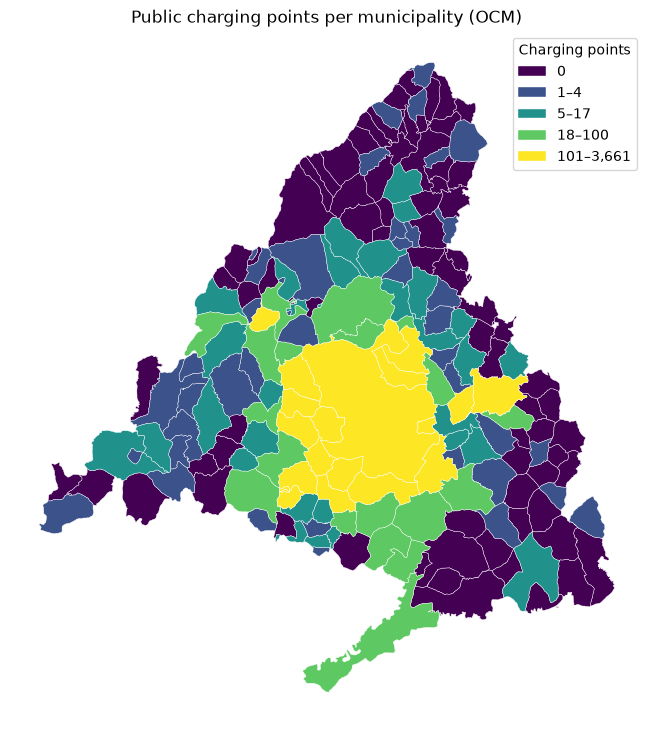

In [11]:
max_pts = int(munis_supply["public_points"].max())

bins = [0, 4, 17, 100, max_pts]
labels = ["0", "1–4", "5–17", "18–100", f"101–{max_pts:,}"]

ax = munis_supply.plot(
    column="public_points",
    scheme="UserDefined",
    classification_kwds={"bins": bins},
    cmap="viridis",
    legend=True,
    legend_kwds={"labels": labels, "title": "Charging points", "loc": "upper right"},
    edgecolor="white",
    linewidth=0.3,
    figsize=(9, 9),
)
ax.set_axis_off()
ax.set_title("Public charging points per municipality (OCM)")

In [16]:
pop = pd.read_csv("data/raw/2881.csv", sep=";", encoding="utf-8-sig", dtype=str)
print(pop.columns.tolist())
pop.head(3)

['Municipios', 'Sexo', 'Periodo', 'Total']


,Municipios,Sexo,Periodo,Total
0,"28001 Acebeda, La",Total,2025,70
1,"28001 Acebeda, La",Total,2024,68
2,"28001 Acebeda, La",Total,2023,67


In [17]:
pop = pop[(pop["Sexo"] == "Total") & pop["Municipios"].str.match(r"^\d{5} ")]   # municipalities only
year = pop["Periodo"].max()
pop = pop[pop["Periodo"] == year]
pop["ine_code"] = pop["Municipios"].str[:5]
pop["population"] = pd.to_numeric(pop["Total"].str.replace(".", "", regex=False), errors="coerce")

munis_supply["ine_code"] = munis_supply["ine_code"].astype(str).str[:5]
munis_supply = (munis_supply.drop(columns=["population", "pts_per_10k"], errors="ignore")
                .merge(pop[["ine_code", "population"]], on="ine_code", how="left"))

print("Population year:", year)
missing = munis_supply[munis_supply["population"].isna()]
print("Municipalities without population match:", len(missing), list(missing["name"]))

munis_supply["pts_per_10k"] = munis_supply["public_points"] / munis_supply["population"] * 10_000
munis_supply.drop(columns="geometry").to_csv("data/processed/muni_supply.csv", index=False)
munis_supply.sort_values("pts_per_10k", ascending=False)[["name", "population", "public_points", "pts_per_10k"]].head(10)

Population year: 2025
Municipalities without population match: 3 [nan, 'El Redegüelo', 'Los Baldíos']


,name,population,public_points,pts_per_10k
163,Somosierra,93.0,2,215.053763
91,Puebla de la Sierra,98.0,2,204.081633
56,Gargantilla del Lozoya y Pinilla de Buitrago,396.0,4,101.010101
79,Horcajo de la Sierra-Aoslos,219.0,2,91.324201
68,Braojos,233.0,2,85.836910
65,Berzosa del Lozoya,242.0,2,82.644628
33,Redueña,288.0,2,69.444444
63,Lozoyuela-Navas-Sieteiglesias,1468.0,10,68.119891
135,San Martín de la Vega,21010.0,94,44.740600
16,Arroyomolinos,38075.0,149,39.133290


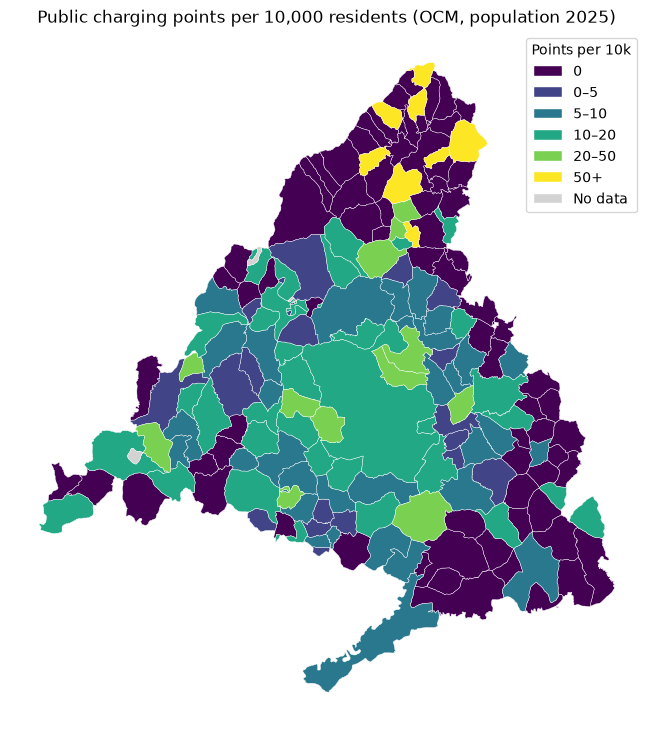

In [20]:
ax = munis_supply.plot(column="pts_per_10k", scheme="user_defined",
                       classification_kwds={"bins": [0, 5, 10, 20, 50, 250]},
                       cmap="viridis", edgecolor="white", linewidth=0.3, figsize=(9, 9),
                       legend=True,
                       legend_kwds={"labels": ["0", "0–5", "5–10", "10–20", "20–50", "50+"],
                                    "title": "Points per 10k"},
                       missing_kwds={"color": "lightgrey", "label": "No data"})
ax.set_axis_off()
ax.set_title(f"Public charging points per 10,000 residents (OCM, population {year})");